# EDA

In [34]:
print(df.shape)

(5600, 8)


In [35]:
print(df.head())

    latitude  longitude  CaseMasterID  CrimeMinorHeadID  GravityOffenceID  \
0  12.963657  77.738260             0                 2                 5   
1  12.961894  77.734746             1                 4                 2   
2  12.965520  77.736749             2                 6                 1   
3  12.961423  77.736299             3                 2                 2   
4  12.961435  77.734283             4                 2                 2   

  incident_month incident_hour_bucket  cluster  
0        2025-09              morning       13  
1        2025-06            afternoon       13  
2        2025-07              morning       13  
3        2025-11              morning       13  
4        2025-06            afternoon       13  


In [36]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5600 entries, 0 to 5599
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   latitude              5600 non-null   float64
 1   longitude             5600 non-null   float64
 2   CaseMasterID          5600 non-null   int64  
 3   CrimeMinorHeadID      5600 non-null   int64  
 4   GravityOffenceID      5600 non-null   int64  
 5   incident_month        5600 non-null   str    
 6   incident_hour_bucket  5600 non-null   str    
 7   cluster               5600 non-null   int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 350.1 KB
None


In [37]:
print(df.describe())

          latitude    longitude  CaseMasterID  CrimeMinorHeadID  \
count  5600.000000  5600.000000   5600.000000       5600.000000   
mean     13.024733    77.600113   2799.500000          5.491964   
std       0.070329     0.093379   1616.725085          2.884130   
min      12.800567    77.400481      0.000000          1.000000   
25%      12.963785    77.495736   1399.750000          3.000000   
50%      13.027774    77.632355   2799.500000          6.000000   
75%      13.074637    77.670655   4199.250000          8.000000   
max      13.199538    77.799323   5599.000000         10.000000   

       GravityOffenceID      cluster  
count       5600.000000  5600.000000  
mean           3.065714     8.585179  
std            1.425272     4.050701  
min            1.000000    -1.000000  
25%            2.000000     7.000000  
50%            3.000000     9.000000  
75%            4.000000    11.000000  
max            5.000000    20.000000  


In [38]:
print(df.isnull().sum())

latitude                0
longitude               0
CaseMasterID            0
CrimeMinorHeadID        0
GravityOffenceID        0
incident_month          0
incident_hour_bucket    0
cluster                 0
dtype: int64


<Axes: xlabel='CrimeMinorHeadID'>

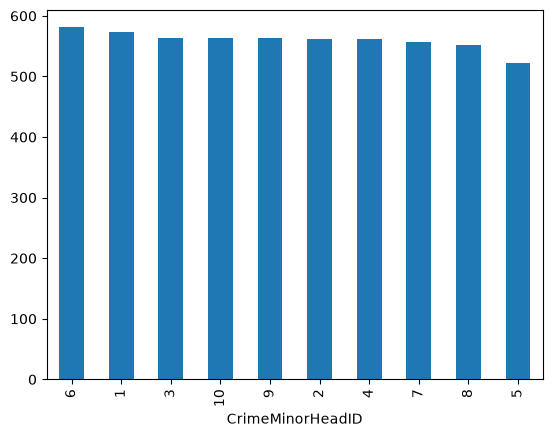

In [39]:
df['CrimeMinorHeadID'].value_counts().plot(kind='bar')

<Axes: xlabel='GravityOffenceID'>

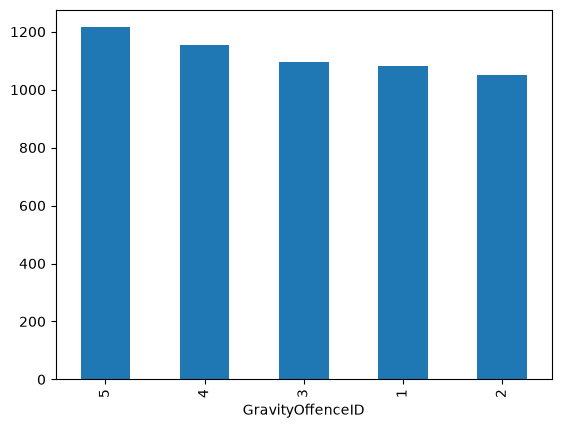

In [40]:
df['GravityOffenceID'].value_counts().plot(kind='bar')

<Axes: xlabel='incident_month'>

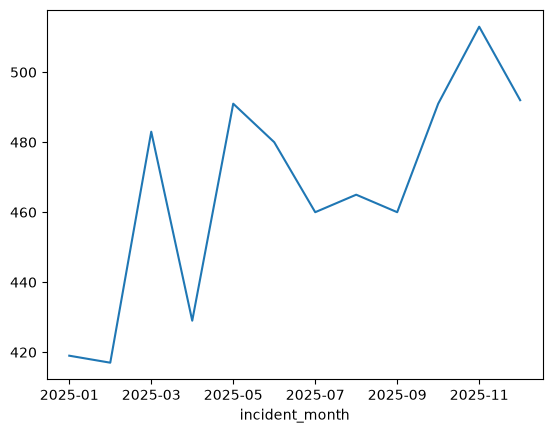

In [41]:
df['incident_month'].value_counts().sort_index().plot(kind='line')

<Axes: xlabel='incident_hour_bucket'>

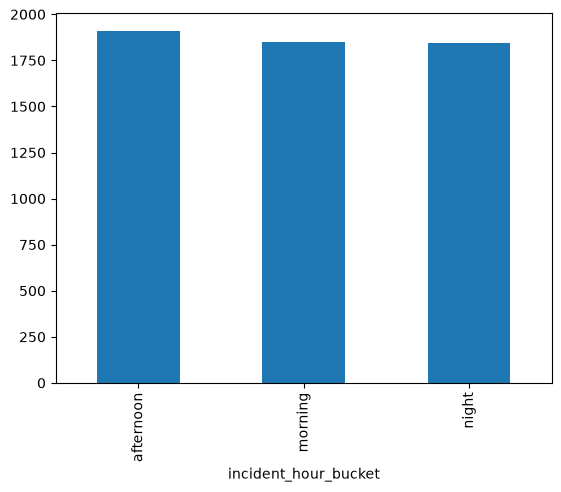

In [42]:
df['incident_hour_bucket'].value_counts().plot(kind='bar')

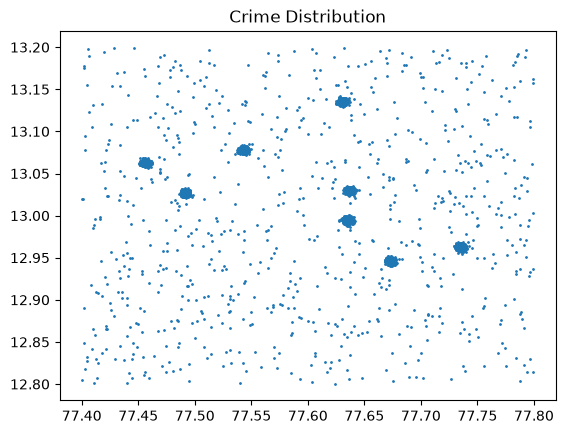

In [43]:
plt.scatter(df['longitude'], df['latitude'], s=1)
plt.title("Crime Distribution")
plt.show()

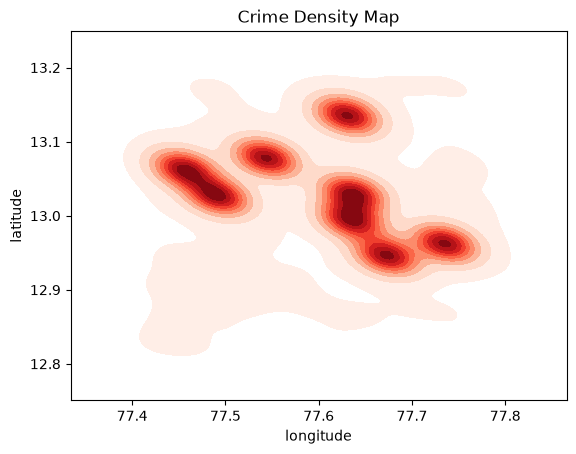

In [44]:
import seaborn as sns

sns.kdeplot(
    x=df['longitude'],
    y=df['latitude'],
    fill=True,
    cmap="Reds"
)
plt.title("Crime Density Map")
plt.show()

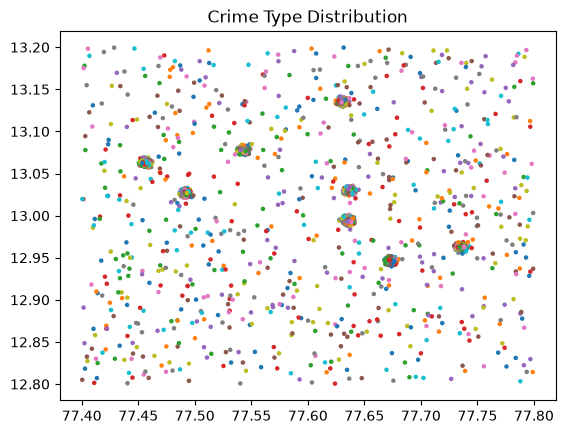

In [45]:
import matplotlib.pyplot as plt

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['CrimeMinorHeadID'],
    cmap='tab10',
    s=5
)
plt.title("Crime Type Distribution")
plt.show()

# Model

In [46]:
import pandas as pd
import numpy as np
import hdbscan

# Load data
df = pd.read_csv("hotspot_points.csv")

# Remove duplicates
df = df.drop_duplicates(subset=['latitude','longitude'])

# Convert to radians (for geo data)
coords = np.radians(df[['latitude', 'longitude']])

# Apply HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,     # similar to min_samples in DBSCAN
    min_samples=5,           # controls noise sensitivity
    metric='haversine'       # same as your DBSCAN
)

labels = clusterer.fit_predict(coords)

# Results
df['cluster'] = labels

print("Clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise:", list(labels).count(-1))

Clusters: 21
Noise: 390


In [47]:
pip install hdbscan


Note: you may need to restart the kernel to use updated packages.


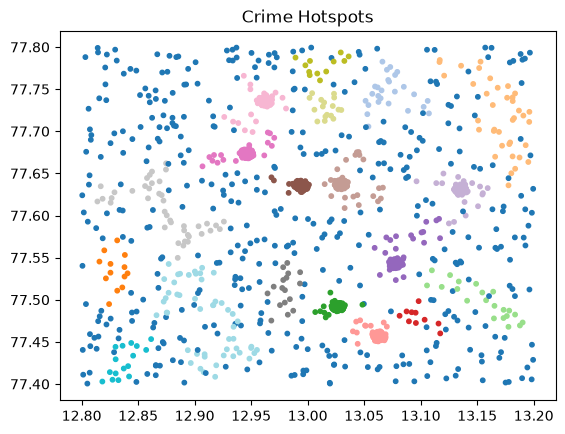

In [48]:
import matplotlib.pyplot as plt

plt.scatter(df['latitude'], df['longitude'], c=df['cluster'], cmap='tab20', s=10)
plt.title("Crime Hotspots")
plt.show()

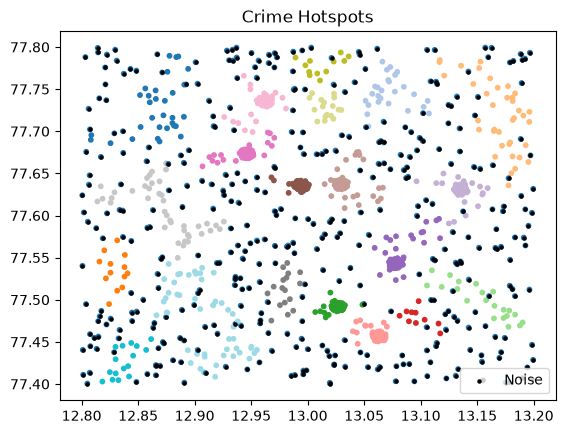

In [49]:
plt.scatter(
    df['latitude'],
    df['longitude'],
    c=df['cluster'],
    cmap='tab20',
    s=10
)

# Highlight noise separately
noise = df['cluster'] == -1
plt.scatter(
    df[noise]['latitude'],
    df[noise]['longitude'],
    c='black',
    s=5,
    label='Noise'
)

plt.legend()
plt.title("Crime Hotspots")
plt.show()

In [50]:
# Remove noise
clusters_df = df[df['cluster'] != -1]

# Group hotspots
hotspots = clusters_df.groupby('cluster').agg({
    'latitude': 'mean',
    'longitude': 'mean',
    'cluster': 'count'
}).rename(columns={'cluster': 'crime_count'}).reset_index()

print(hotspots)

    cluster   latitude  longitude  crime_count
0         0  12.867102  77.727223           31
1         1  13.072604  77.745508           26
2         2  12.829728  77.534270           13
3         3  13.169014  77.718507           38
4         4  13.026575  77.491768          610
5         5  13.155412  77.498279           21
6         6  13.097654  77.479013           10
7         7  13.062544  77.456434          610
8         8  13.078203  77.544306          621
9         9  13.135380  77.630521          617
10       10  12.994245  77.635323          606
11       11  13.030174  77.637204          620
12       12  12.946040  77.673300          616
13       13  12.962235  77.735125          617
14       14  12.979894  77.511710           17
15       15  12.873678  77.606821           41
16       16  13.012440  77.777891           12
17       17  13.016325  77.727715           17
18       18  12.837936  77.426724           16
19       19  12.925445  77.450124           30
20       20  

In [51]:
hotspots.to_csv("clean_hotspots.csv", index=False)

In [52]:
from sklearn.metrics.pairwise import haversine_distances

# Function to assign new point
def predict_hotspot(lat, lon, hotspots):
    point = np.radians([[lat, lon]])
    centers = np.radians(hotspots[['latitude', 'longitude']])
    
    distances = haversine_distances(point, centers)
    closest = np.argmin(distances)
    
    return hotspots.iloc[closest]

# Example test
test_lat = 12.98
test_lon = 77.66

result = predict_hotspot(test_lat, test_lon, hotspots)
print(result)

cluster         10.000000
latitude        12.994245
longitude       77.635323
crime_count    606.000000
Name: 10, dtype: float64
